# Ejercicio 7 - Indicadores y visualizacion

Indicadores construidos sobre la base materializada
`data/processed/taxis.duckdb` (`scripts/materializar.py`, 2024 + 2026). Cada
indicador tiene su consulta en `sql/07_indicadores/` (pregunta, definicion,
fuente y visualizacion en el encabezado).

Las visualizaciones del tablero se crean en **Metabase**, la herramienta del
ambiente, con `scripts/metabase_indicadores.py`. Este notebook dibuja los
mismos resultados con matplotlib para dejar evidencia versionada en
`docs/figuras/ej7_*.png`. La documentacion esta en
`docs/07_indicadores.md`.

La base se abre en **solo lectura**, por lo que el notebook puede ejecutarse
mientras Metabase tiene la base abierta.

In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "scripts"))
from run_sql import conectar, encabezado

con = conectar(base=str(RAIZ / "data" / "processed" / "taxis.duckdb"), solo_lectura=True)
DIR_SQL = RAIZ / "sql" / "07_indicadores"
DIR_FIGURAS = RAIZ / "docs" / "figuras"
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 120)


def ejecutar(nombre: str) -> pd.DataFrame:
    """Muestra el encabezado de sql/07_indicadores/<nombre> y devuelve su resultado."""
    ruta = DIR_SQL / nombre
    print(chr(10).join(encabezado(ruta)))
    inicio = time.perf_counter()
    df = con.sql(ruta.read_text(encoding="utf-8")).df()
    print(f"-- tiempo: {time.perf_counter() - inicio:.2f} s")
    return df


# --- Estilo (mismo que notebooks/04; paleta de referencia de la skill dataviz)
# Colores fijos por entidad: un anio conserva su color aunque se agreguen
# otros (2025 queda reservado para el Ejercicio 8).
COLOR_ANIO = {"2024": "#2a78d6", "2025": "#1baf7a", "2026": "#eb6834"}   # azul, aqua, naranja
COLOR_TIPO = {"yellow": "#eda100", "green": "#008300"}
COLOR_METODO = {"Tarjeta": "#2a78d6", "Flex Fare": "#eb6834", "Efectivo": "#1baf7a", "Otros": "#898781"}
GRIS = "#898781"
TINTA, TINTA_2, REJILLA, EJE = "#0b0b0b", "#52514e", "#e1e0d9", "#c3c2b7"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "savefig.facecolor": "#fcfcfb",
    "font.family": "sans-serif", "font.size": 10,
    "text.color": TINTA, "axes.labelcolor": TINTA_2, "axes.titlecolor": TINTA,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "xtick.color": GRIS, "ytick.color": GRIS, "axes.edgecolor": EJE,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": REJILLA, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "lines.linewidth": 2, "lines.markersize": 8, "legend.frameon": False, "figure.dpi": 110,
})
MESES = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]
miles = mticker.FuncFormatter(lambda x, _: f"{x:,.0f}")
porcentaje = mticker.FuncFormatter(lambda x, _: f"{x:g}%")


def guardar(fig, nombre: str):
    fig.savefig(DIR_FIGURAS / f"{nombre}.png", dpi=130, bbox_inches="tight")


def lineas_por_anio(ax, df, x, y, etiqueta_final=None):
    """Una linea por anio con su color fijo y etiqueta directa al final."""
    for anio, d in df.groupby("anio"):
        ax.plot(d[x], d[y], color=COLOR_ANIO[anio], marker="o", markersize=5, label=anio)
        ultimo = d.iloc[-1]
        texto = etiqueta_final(ultimo[y]) if etiqueta_final else anio
        ax.annotate(f"{anio}: {texto}" if etiqueta_final else anio, (ultimo[x], ultimo[y]),
                    xytext=(6, 0), textcoords="offset points", va="center", fontsize=9, color=TINTA_2)
    ax.legend(loc="best")


print(con.sql("SELECT * FROM carga").df().T)

                                      0
fecha_carga  2026-10-08 05:19:16.907856
periodo                             */*
archivos                             40
filas                          71870407
segundos                      23.369381
anios                      [2024, 2026]
ultimo_mes                      2026-08


## I1 - Viajes por mes

**P1.** ¿Cuantos viajes se realizan cada mes y como se compara la demanda de
un anio con la del otro?

In [2]:
i1 = ejecutar("01_viajes_por_mes.sql")
i1.pivot(index="mes", columns="anio", values="viajes")

-- Indicador 1 - Viajes por mes
-- Pregunta: P1. ¿Cuantos viajes se realizan cada mes y como se compara la
--           demanda de un anio con la del otro?
-- Indicador: cantidad de viajes registrados por mes calendario, una serie
--           por anio (yellow + green). Se usa la tabla viajes completa (no
--           viajes_validos): un registro con una hora o distancia mal
--           capturada sigue siendo un viaje realizado.
-- Fuente:   data/processed/taxis.duckdb, tabla viajes (scripts/materializar.py)
-- Visualizacion: lineas; x = mes, y = viajes, serie = anio.


-- tiempo: 0.25 s


anio,2024,2026
mes,,
1,3021175.0,3765161.0
2,3061103.0,3437239.0
3,3640085.0,3996659.0
4,3570760.0,3875478.0
5,3784836.0,4135757.0
6,3593941.0,3881411.0
7,3128740.0,3571361.0
8,3030954.0,3377403.0
9,3687470.0,NaN


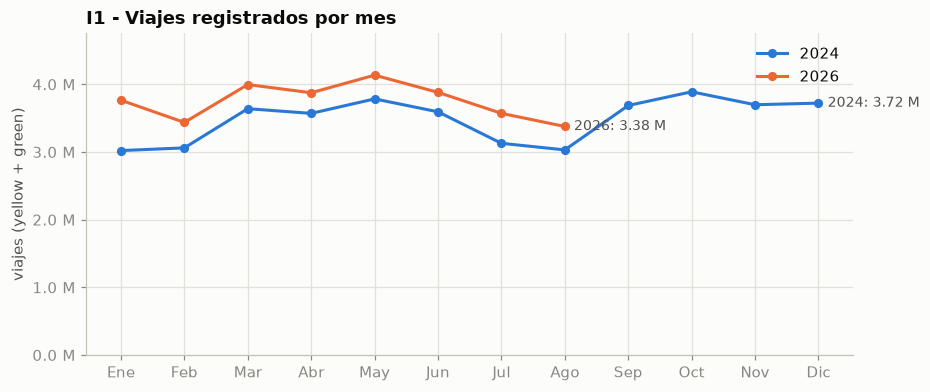

In [3]:
fig, ax = plt.subplots(figsize=(9, 3.8))
lineas_por_anio(ax, i1, "mes", "viajes", lambda v: f"{v / 1e6:.2f} M")
ax.set_xticks(range(1, 13), MESES)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x / 1e6:.1f} M"))
ax.set_ylim(0, i1.viajes.max() * 1.15)
ax.set_ylabel("viajes (yellow + green)")
ax.set_title("I1 - Viajes registrados por mes")
guardar(fig, "ej7_i1_viajes_por_mes")

## I2 - Variacion interanual por tipo de taxi

**P2.** ¿La demanda crece o cae respecto al mismo mes del anio anterior
disponible, y evolucionan igual yellow y green?

In [4]:
i2 = ejecutar("02_variacion_interanual.sql")
i2.pivot(index="mes", columns="serie", values="variacion_pct")

-- Indicador 2 - Variacion interanual de viajes por tipo de taxi
-- Pregunta: P2. ¿La demanda crece o cae respecto al mismo mes del anio
--           anterior disponible, y evolucionan igual yellow y green?
-- Indicador: (viajes del mes / viajes del mismo mes del anio anterior
--           disponible - 1) x 100, por tipo de taxi. Comparar el mismo mes
--           elimina la estacionalidad.
-- Fuente:   data/processed/taxis.duckdb, tabla viajes
-- Nota:     el "anio anterior disponible" es el anio cargado inmediatamente
--           anterior (hoy 2026 frente a 2024; al agregar 2025 en el
--           Ejercicio 8 seran 2025 vs 2024 y 2026 vs 2025, sin cambiar la
--           consulta).
-- Visualizacion: barras; x = mes, y = variacion_pct, serie = serie (tipo + comparacion).


-- tiempo: 0.21 s


serie,green 2026 vs 2024,yellow 2026 vs 2024
mes,,
1,-28.8,25.6
2,-30.2,13.0
3,-23.1,10.3
4,-21.7,9.0
5,-26.4,9.9
6,-19.3,8.4
7,-20.4,14.7
8,-21.4,12.0


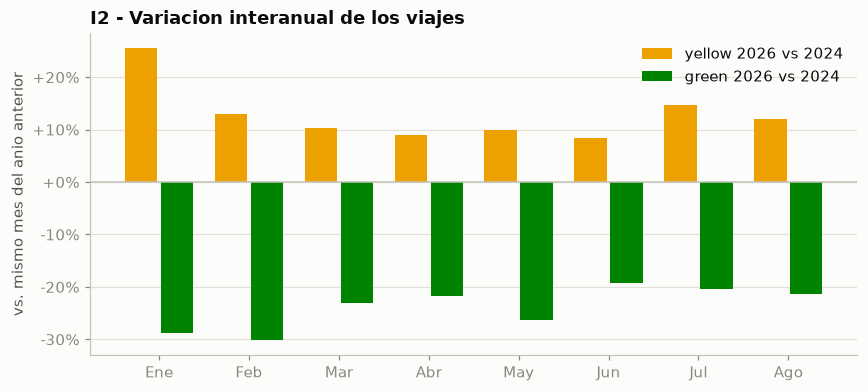

In [5]:
fig, ax = plt.subplots(figsize=(9, 3.8))
series = list(dict.fromkeys(i2.serie))
ancho = 0.8 / len(series)
for k, serie in enumerate(series):
    d = i2[i2.serie == serie]
    tipo = serie.split()[0]
    ax.bar(d.mes + (k - (len(series) - 1) / 2) * ancho, d.variacion_pct, width=ancho - 0.04,
           color=COLOR_TIPO[tipo], label=serie)
ax.axhline(0, color=EJE, linewidth=1)
ax.set_xticks(sorted(i2.mes.unique()), [MESES[m - 1] for m in sorted(i2.mes.unique())])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:+.0f}%"))
ax.set_ylabel("vs. mismo mes del anio anterior")
ax.set_title("I2 - Variacion interanual de los viajes")
ax.legend(loc="upper right")
ax.grid(axis="x", visible=False)
guardar(fig, "ej7_i2_variacion_interanual")

## I3 - Costo tipico de un viaje

**P3.** ¿Cuanto paga un pasajero por un viaje tipico y como cambia ese monto
en el tiempo?

In [6]:
i3 = ejecutar("03_costo_por_viaje.sql")
i3

-- Indicador 3 - Costo tipico de un viaje por mes
-- Pregunta: P3. ¿Cuanto paga un pasajero por un viaje tipico y como cambia
--           ese monto en el tiempo?
-- Indicador: mediana de total_amount por viaje, por mes y anio (taxis
--           amarillos). Se usa la mediana porque la distribucion de montos es
--           asimetrica (viajes de aeropuerto y largos elevan el promedio).
-- Fuente:   data/processed/taxis.duckdb, vista viajes_validos
-- Nota:     solo yellow (95%+ de los viajes): mezclar con green, que tiene
--           otra tarifa y otra cobertura, cambiaria la mediana por cambios de
--           composicion y no de precio. Se excluyen montos en cero.
-- Visualizacion: lineas; x = mes, y = total_mediano_usd, serie = anio.


-- tiempo: 4.70 s


,mes,anio,total_mediano_usd,tarifa_mediana_usd,distancia_mediana_mi
0,1,2024,20.16,12.80,1.70
1,2,2024,20.43,12.80,1.72
2,3,2024,20.64,13.50,1.80
3,4,2024,21.00,13.82,1.81
4,5,2024,21.60,14.20,1.81
5,6,2024,21.35,14.20,1.82
6,7,2024,21.00,14.20,1.83
7,8,2024,21.00,14.20,1.85
8,9,2024,21.84,14.90,1.85
9,10,2024,21.84,14.20,1.80


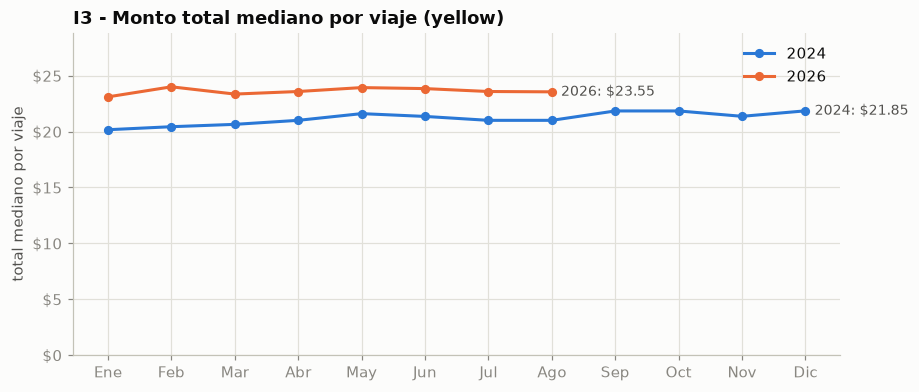

In [7]:
fig, ax = plt.subplots(figsize=(9, 3.8))
lineas_por_anio(ax, i3, "mes", "total_mediano_usd", lambda v: f"${v:.2f}")
ax.set_xticks(range(1, 13), MESES)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}"))
ax.set_ylim(0, i3.total_mediano_usd.max() * 1.2)
ax.set_ylabel("total mediano por viaje")
ax.set_title("I3 - Monto total mediano por viaje (yellow)")
guardar(fig, "ej7_i3_costo_por_viaje")

## I4 - Composicion del cobro

**P4.** ¿Que componentes explican lo que se cobra por un viaje y cuanto aporta
el cargo por congestion (CBD) introducido en 2025?

In [8]:
i4 = ejecutar("04_composicion_del_cobro.sql")
i4.pivot(index="componente", columns="anio", values="usd_promedio").assign(
    diferencia=lambda d: d.iloc[:, -1] - d.iloc[:, 0])

-- Indicador 4 - Composicion del cobro promedio por viaje
-- Pregunta: P4. ¿Que componentes explican lo que se cobra por un viaje y
--           cuanto aporta el cargo por congestion (CBD) introducido en 2025?
-- Indicador: promedio por viaje, en USD, de cada componente de total_amount:
--           tarifa base, propina, peajes, cargo de aeropuerto, cargo CBD y
--           otros recargos (extra, MTA, mejora, congestion_surcharge = el
--           resto del total).
-- Fuente:   data/processed/taxis.duckdb, vista viajes_validos
-- Nota:     solo yellow y solo los meses publicados en TODOS los anios
--           cargados (hoy enero-agosto), para comparar periodos equivalentes.
--           Los cargos ausentes (NULL, p. ej. CBD en 2024) cuentan como 0.
-- Visualizacion: barras apiladas; x = anio, y = usd_promedio, serie = componente.


-- tiempo: 1.29 s


anio,2024,2026,diferencia
componente,,,
1 Tarifa base,19.53,21.29,1.76
2 Propina,3.34,2.88,-0.46
3 Peajes,0.58,0.55,-0.03
4 Cargo aeropuerto,0.14,0.13,-0.01
5 Cargo congestion CBD,0.00,0.54,0.54
6 Otros recargos,4.74,4.85,0.11


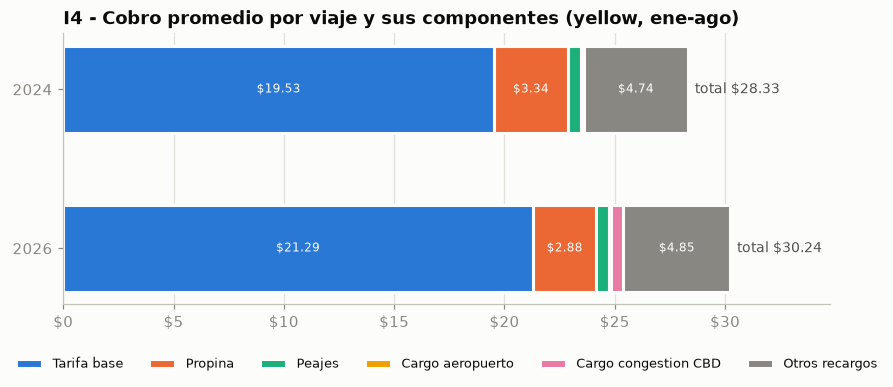

In [9]:
p = i4.pivot(index="anio", columns="componente", values="usd_promedio")
colores = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#898781"]
fig, ax = plt.subplots(figsize=(9, 3.2))
izquierda = pd.Series(0.0, index=p.index)
for color, componente in zip(colores, p.columns):
    ax.barh(p.index, p[componente], left=izquierda, color=color, height=0.55,
            label=componente[2:], edgecolor="#fcfcfb", linewidth=2)
    for anio in p.index:
        if p.loc[anio, componente] >= 1:
            ax.text(izquierda[anio] + p.loc[anio, componente] / 2, anio, f"${p.loc[anio, componente]:.2f}",
                    ha="center", va="center", fontsize=8, color="#ffffff")
    izquierda += p[componente]
for anio in p.index:
    ax.text(izquierda[anio] + 0.3, anio, f"total ${izquierda[anio]:.2f}", va="center", fontsize=9, color=TINTA_2)
ax.set_xlim(0, izquierda.max() * 1.15)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}"))
ax.set_title("I4 - Cobro promedio por viaje y sus componentes (yellow, ene-ago)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncols=6, fontsize=8.5)
ax.grid(axis="y", visible=False)
ax.invert_yaxis()
guardar(fig, "ej7_i4_composicion_cobro")

## I5 - Metodos de pago

**P5.** ¿Como pagan los pasajeros y esta cambiando la mezcla de metodos de
pago?

In [10]:
i5 = ejecutar("05_metodos_de_pago.sql")
i5.pivot(index="mes", columns="metodo_pago", values="pct_del_mes")

-- Indicador 5 - Participacion de cada metodo de pago por mes
-- Pregunta: P5. ¿Como pagan los pasajeros y esta cambiando la mezcla de
--           metodos de pago?
-- Indicador: % de los viajes de cada mes pagados con cada metodo (yellow +
--           green). Tarjeta, efectivo y Flex Fare se muestran por separado; el
--           resto (sin cargo, disputa, desconocido, anulado) se agrupa.
-- Fuente:   data/processed/taxis.duckdb, tabla viajes + tabla metodos_pago
-- Nota:     se usa viajes (no viajes_validos), igual que en el Ejercicio 4:
--           los filtros de validez eliminan casi todas las disputas. En green
--           el equivalente a Flex Fare llega con payment_type NULL.
-- Visualizacion: barras apiladas al 100%; x = mes (YYYY-MM), serie = metodo.


-- tiempo: 0.51 s


metodo_pago,Efectivo,Flex Fare,Otros,Tarjeta
mes,,,,
2024-01,15.06,4.75,2.21,77.97
2024-02,13.98,6.16,2.19,77.67
2024-03,13.58,11.77,2.26,72.40
2024-04,13.59,11.50,2.25,72.66
2024-05,13.70,10.74,2.36,73.19
2024-06,13.48,11.48,2.46,72.57
2024-07,14.97,8.97,2.91,73.15
2024-08,15.28,8.59,3.14,72.99
2024-09,12.45,13.16,2.71,71.68


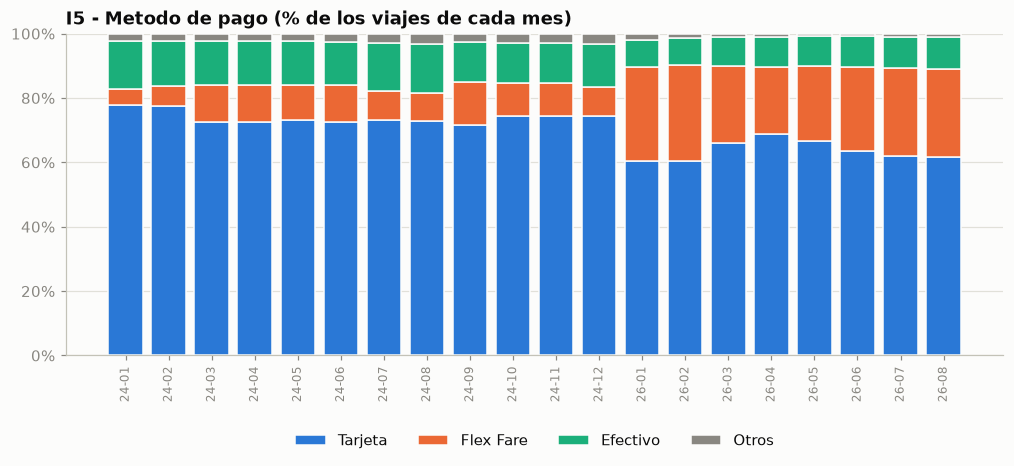

In [11]:
p = i5.pivot(index="mes", columns="metodo_pago", values="pct_del_mes")[list(COLOR_METODO)]
fig, ax = plt.subplots(figsize=(11, 3.8))
base = pd.Series(0.0, index=p.index)
for metodo, color in COLOR_METODO.items():
    ax.bar(range(len(p)), p[metodo], bottom=base, color=color, width=0.8, label=metodo,
           edgecolor="#fcfcfb", linewidth=1)
    base += p[metodo]
ax.set_xticks(range(len(p)), [m[2:4] + "-" + m[5:] for m in p.index], fontsize=8, rotation=90)
ax.yaxis.set_major_formatter(porcentaje)
ax.set_ylim(0, 100)
ax.set_title("I5 - Metodo de pago (% de los viajes de cada mes)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncols=4)
ax.grid(axis="x", visible=False)
guardar(fig, "ej7_i5_metodos_pago")

## I6 - Propina con tarjeta

**P6.** ¿Que tan generosas son las propinas y cambian entre anios?

In [12]:
i6 = ejecutar("06_propina_con_tarjeta.sql")
i6

-- Indicador 6 - Propina en pagos con tarjeta
-- Pregunta: P6. ¿Que tan generosas son las propinas y cambian entre anios?
-- Indicador: % de los viajes pagados con tarjeta que incluyen propina, por
--           mes y anio. Como referencia se agrega la propina promedio como %
--           de lo cobrado antes de ella (recortada a [0, 100]%).
-- Decision: la propina MEDIANA no sirve como indicador: es exactamente 20%
--           en todos los meses de ambos anios (la opcion sugerida por la
--           pantalla de pago), mientras que la proporcion de pasajeros que
--           deja propina si cambia.
-- Fuente:   data/processed/taxis.duckdb, vista viajes_validos
-- Nota:     solo tarjeta (payment_type = 1): en efectivo la propina casi
--           nunca se registra (Ejercicio 4, consulta 14). Yellow + green.
-- Visualizacion: lineas; x = mes, y = pct_con_propina, serie = anio.


-- tiempo: 0.74 s


,mes,anio,viajes_tarjeta,pct_con_propina,pct_propina_promedio
0,1,2024,2332965,95.3,17.8
1,2,2024,2355548,95.1,17.7
2,3,2024,2611701,94.8,17.7
3,4,2024,2572150,94.7,17.6
4,5,2024,2745481,94.6,17.6
5,6,2024,2583826,94.2,17.5
6,7,2024,2265402,93.3,17.3
7,8,2024,2187521,92.9,17.3
8,9,2024,2617326,94.1,17.4
9,10,2024,2867150,94.4,17.5


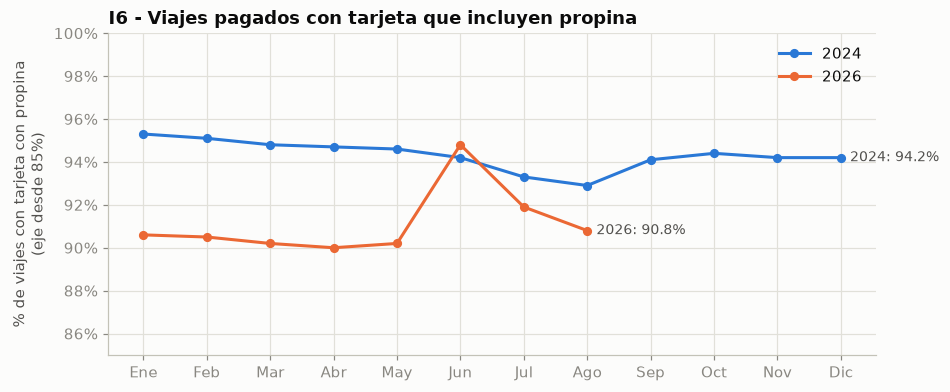

In [13]:
fig, ax = plt.subplots(figsize=(9, 3.8))
lineas_por_anio(ax, i6, "mes", "pct_con_propina", lambda v: f"{v:.1f}%")
ax.set_xticks(range(1, 13), MESES)
ax.yaxis.set_major_formatter(porcentaje)
ax.set_ylim(85, 100)
ax.set_ylabel("% de viajes con tarjeta con propina\n(eje desde 85%)")
ax.set_title("I6 - Viajes pagados con tarjeta que incluyen propina")
guardar(fig, "ej7_i6_propina")

## I7 - Demanda por hora

**P7.** ¿En que horas se concentra la demanda en dias laborables y en fines de
semana, y se mantiene el patron entre anios?

In [14]:
i7 = ejecutar("07_demanda_por_hora.sql")
i7.pivot(index="hora", columns="serie", values="viajes_promedio")

-- Indicador 7 - Demanda promedio por hora del dia
-- Pregunta: P7. ¿En que horas se concentra la demanda en dias laborables y
--           en fines de semana, y se mantiene el patron entre anios?
-- Indicador: viajes promedio que inician en cada hora (viajes de la hora /
--           fechas de ese tipo de dia), por tipo de dia y anio.
-- Fuente:   data/processed/taxis.duckdb, tabla viajes
-- Nota:     solo los meses publicados en todos los anios (hoy enero-agosto)
--           para no mezclar estacionalidad, y solo viajes cuya fecha cae en
--           el anio de su archivo. Se divide entre el numero de fechas de
--           cada tipo de dia.
-- Visualizacion: lineas; x = hora, y = viajes_promedio, serie = serie (anio + tipo de dia).


-- tiempo: 1.02 s


serie,2024 fin de semana,2024 laborable,2026 fin de semana,2026 laborable
hora,,,,
0,5744.0,2062.0,7104.0,2553.0
1,4619.0,1012.0,5600.0,1348.0
2,3291.0,563.0,4062.0,770.0
3,2173.0,376.0,2973.0,536.0
4,1269.0,405.0,1993.0,622.0
5,573.0,745.0,1028.0,1160.0
6,909.0,1816.0,1296.0,2431.0
7,1340.0,3646.0,1672.0,4492.0
8,2054.0,5046.0,2426.0,5958.0


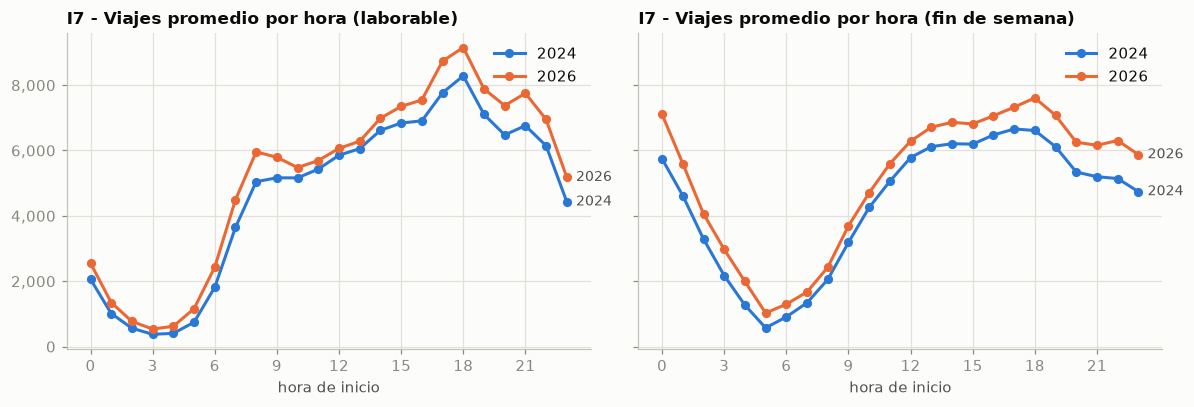

In [15]:
i7[["anio", "tipo_dia"]] = i7.serie.str.split(" ", n=1, expand=True)
fig, ejes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, tipo_dia in zip(ejes, ["laborable", "fin de semana"]):
    lineas_por_anio(ax, i7[i7.tipo_dia == tipo_dia], "hora", "viajes_promedio")
    ax.set_title(f"I7 - Viajes promedio por hora ({tipo_dia})", fontsize=11)
    ax.set_xticks(range(0, 24, 3))
    ax.set_xlabel("hora de inicio")
    ax.yaxis.set_major_formatter(miles)
fig.tight_layout()
guardar(fig, "ej7_i7_demanda_por_hora")

## I8 - Velocidad en Manhattan

**P8.** ¿Que tan congestionado esta el trafico a cada hora y cambio la
velocidad despues de la tarifa de congestion de 2025?

In [16]:
i8 = ejecutar("08_velocidad_manhattan.sql")
i8.pivot(index="hora", columns="anio", values="velocidad_mediana_mph").assign(
    diferencia=lambda d: d.iloc[:, -1] - d.iloc[:, 0])

-- Indicador 8 - Velocidad mediana de los viajes dentro de Manhattan por hora
-- Pregunta: P8. ¿Que tan congestionado esta el trafico a cada hora y cambio
--           la velocidad despues de la tarifa de congestion de 2025?
-- Indicador: mediana de distancia / duracion (millas por hora) de los
--           viajes yellow que empiezan y terminan en Manhattan, en dias
--           laborables, por hora y anio. La velocidad del taxi es una medida
--           indirecta del trafico.
-- Fuente:   data/processed/taxis.duckdb, vista viajes_validos + tabla zonas
-- Nota:     el cargo CBD (enero de 2025) se cobra al entrar a Manhattan al sur
--           de la calle 60, por lo que Manhattan es donde deberia notarse un
--           cambio. Se excluyen viajes de menos de 1 minuto o con velocidad
--           mayor a 60 mph (errores de registro). Solo meses publicados en
--           todos los anios (hoy enero-agosto): el trafico es estacional.
-- Visualizacion: lineas; x = hora, y = velocidad_medi

-- tiempo: 5.92 s


anio,2024,2026,diferencia
hora,,,
0,12.1,11.8,-0.3
1,12.8,12.7,-0.1
2,13.1,13.3,0.2
3,13.6,13.8,0.2
4,14.3,14.5,0.2
5,13.8,14.0,0.2
6,12.8,12.6,-0.2
7,10.4,10.2,-0.2
8,8.5,8.4,-0.1


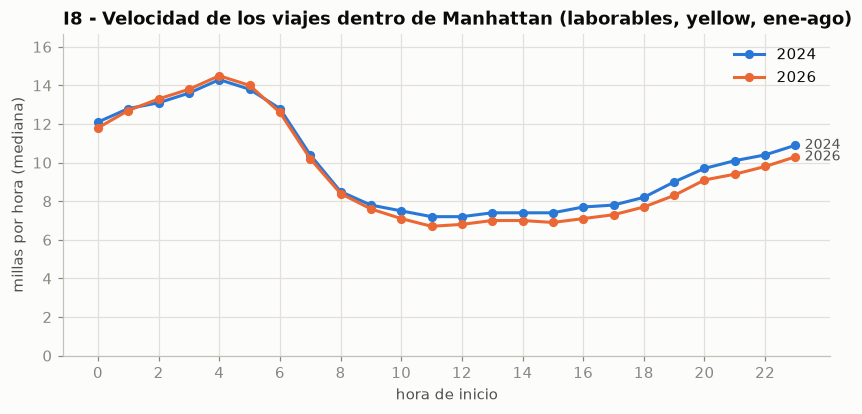

In [17]:
fig, ax = plt.subplots(figsize=(9, 3.8))
lineas_por_anio(ax, i8, "hora", "velocidad_mediana_mph")
ax.set_xticks(range(0, 24, 2))
ax.set_ylim(0, i8.velocidad_mediana_mph.max() * 1.15)
ax.set_xlabel("hora de inicio")
ax.set_ylabel("millas por hora (mediana)")
ax.set_title("I8 - Velocidad de los viajes dentro de Manhattan (laborables, yellow, ene-ago)")
guardar(fig, "ej7_i8_velocidad_manhattan")

## I9 - Zonas de origen

**P9.** ¿Donde se origina la demanda y cambiaron las zonas principales entre
anios?

In [18]:
i9 = ejecutar("09_zonas_de_origen.sql")
i9.pivot(index=["posicion", "zona"], columns="anio", values="pct_viajes")

-- Indicador 9 - Zonas con mas viajes de origen
-- Pregunta: P9. ¿Donde se origina la demanda y cambiaron las zonas
--           principales entre anios?
-- Indicador: % de los viajes de cada anio que inicia en cada una de las 10
--           zonas con mas viajes del anio mas reciente.
-- Fuente:   data/processed/taxis.duckdb, tabla viajes + tabla zonas
-- Nota:     solo meses publicados en todos los anios (hoy enero-agosto), y
--           porcentajes sobre el total del anio. Yellow + green.
-- Visualizacion: barras horizontales; y = zona, x = pct_viajes, serie = anio.


-- tiempo: 0.50 s


,anio,2024,2026
posicion,zona,,
1,Upper East Side South (Manhattan),4.45,4.35
2,Midtown Center (Manhattan),4.66,4.07
3,JFK Airport (Queens),4.78,3.93
4,Upper East Side North (Manhattan),4.08,3.90
5,Penn Station/Madison Sq West (Manhattan),3.24,3.01
6,Midtown East (Manhattan),3.43,3.00
7,Times Sq/Theatre District (Manhattan),3.35,2.84
8,Lincoln Square East (Manhattan),3.11,2.82
9,East Village (Manhattan),2.29,2.63


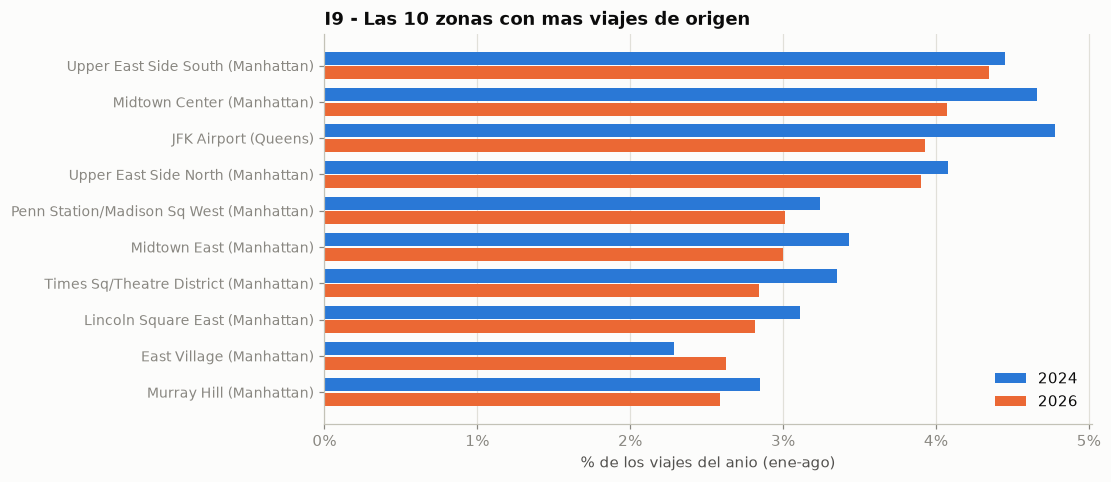

In [19]:
p = i9.pivot(index=["posicion", "zona"], columns="anio", values="pct_viajes").droplevel(0).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 4.6))
alto = 0.8 / len(p.columns)
for k, anio in enumerate(p.columns):
    # el primer anio arriba de cada par, igual que en la leyenda
    ax.barh([i - (k - (len(p.columns) - 1) / 2) * alto for i in range(len(p))], p[anio],
            height=alto - 0.04, color=COLOR_ANIO[anio], label=anio)
ax.set_yticks(range(len(p)), p.index, fontsize=9)
ax.xaxis.set_major_formatter(porcentaje)
ax.set_xlabel("% de los viajes del anio (ene-ago)")
ax.set_title("I9 - Las 10 zonas con mas viajes de origen")
ax.legend(loc="lower right")
ax.grid(axis="y", visible=False)
guardar(fig, "ej7_i9_zonas_origen")

## I10 - Aeropuertos

**P10.** ¿Que parte de los viajes y de los ingresos corresponde a viajes desde
o hacia los aeropuertos?

In [20]:
i10 = ejecutar("10_aeropuertos.sql")
i10.pivot(index="aeropuerto", columns="serie", values="pct")

-- Indicador 10 - Peso de los aeropuertos en viajes e ingresos
-- Pregunta: P10. ¿Que parte de los viajes y de los ingresos corresponde a
--           viajes desde o hacia los aeropuertos?
-- Indicador: % de viajes y % de ingresos (total_amount) de los viajes cuyo
--           origen o destino es JFK (132), LaGuardia (138) o Newark (1), por
--           anio y aeropuerto.
-- Fuente:   data/processed/taxis.duckdb, vista viajes_validos + tabla zonas
-- Nota:     solo meses publicados en todos los anios (hoy enero-agosto). Un
--           viaje entre dos aeropuertos se asigna al de origen. Yellow + green.
-- Formato largo (una fila por aeropuerto, anio y medida) para graficar las
-- dos medidas de ambos anios juntas: si % ingresos > % viajes, el viaje de
-- aeropuerto cuesta mas que el promedio.
-- Visualizacion: barras; x = aeropuerto, y = pct, serie = serie (anio + medida).


-- tiempo: 3.11 s


serie,2024 % ingresos,2024 % viajes,2026 % ingresos,2026 % viajes
aeropuerto,,,,
JFK Airport,16.40,5.54,12.36,4.59
LaGuardia Airport,10.25,4.28,7.79,3.35
Newark Airport,1.11,0.25,0.75,0.17


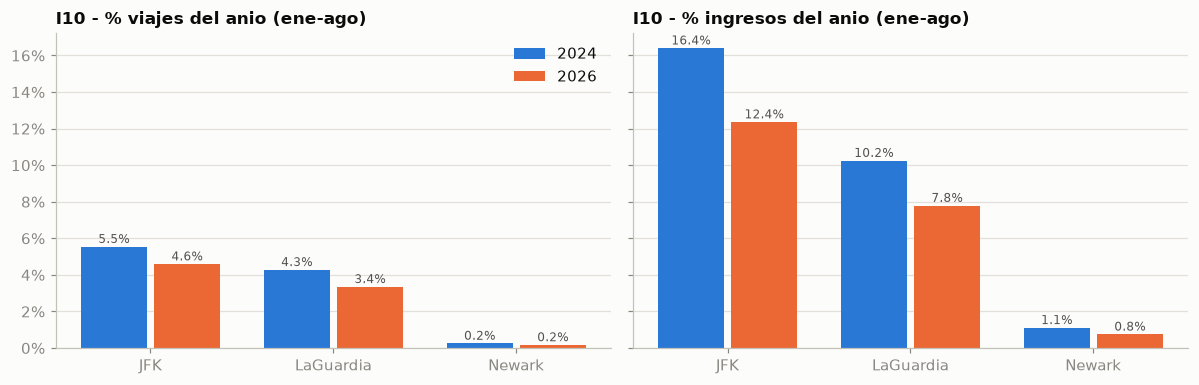

In [21]:
i10[["anio", "medida"]] = i10.serie.str.split(" ", n=1, expand=True)
fig, ejes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, medida in zip(ejes, ["% viajes", "% ingresos"]):
    p = i10[i10.medida == medida].pivot(index="aeropuerto", columns="anio", values="pct")
    ancho = 0.8 / len(p.columns)
    for k, anio in enumerate(p.columns):
        x = [i + (k - (len(p.columns) - 1) / 2) * ancho for i in range(len(p))]
        ax.bar(x, p[anio], width=ancho - 0.04, color=COLOR_ANIO[anio], label=anio)
        for xi, v in zip(x, p[anio]):
            ax.text(xi, v + 0.2, f"{v:.1f}%", ha="center", fontsize=8, color=TINTA_2)
    ax.set_xticks(range(len(p)), [a.replace(" Airport", "") for a in p.index])
    ax.yaxis.set_major_formatter(porcentaje)
    ax.set_title(f"I10 - {medida} del anio (ene-ago)", fontsize=11)
    ax.grid(axis="x", visible=False)
ejes[0].legend(loc="upper right")
fig.tight_layout()
guardar(fig, "ej7_i10_aeropuertos")

## I11 - Calidad de los datos

**P11.** ¿Que tan confiables son los registros de cada mes? ¿Empeora o mejora
la calidad de los datos?

In [22]:
i11 = ejecutar("11_calidad_de_datos.sql")
i11.pivot(index="mes", columns="tipo", values="pct_invalidos")

-- Indicador 11 - Registros que no pasan las reglas de calidad
-- Pregunta: P11. ¿Que tan confiables son los registros de cada mes y
--           proveedor? ¿Empeora o mejora la calidad de los datos?
-- Indicador: % de los registros de cada mes que quedan fuera de
--           viajes_validos (reglas del Ejercicio 3), por tipo de taxi.
-- Fuente:   data/processed/taxis.duckdb, tabla viajes + vista viajes_validos
-- Nota:     un % alto no significa viajes falsos sino registros con datos
--           imposibles (p. ej. hora de fin igual a la de inicio); el
--           Ejercicio 5 mostro que en 2026 el proveedor Helix aporta casi
--           todos los de duracion cero.
-- Visualizacion: lineas; x = mes (YYYY-MM), y = pct_invalidos, serie = tipo.


-- tiempo: 0.58 s


tipo,green,yellow
mes,,
2024-01,5.37,3.19
2024-02,5.57,3.52
2024-03,5.52,3.97
2024-04,5.92,2.84
2024-05,5.37,2.84
2024-06,5.22,3.12
2024-07,6.02,3.34
2024-08,5.47,3.75
2024-09,5.33,4.09


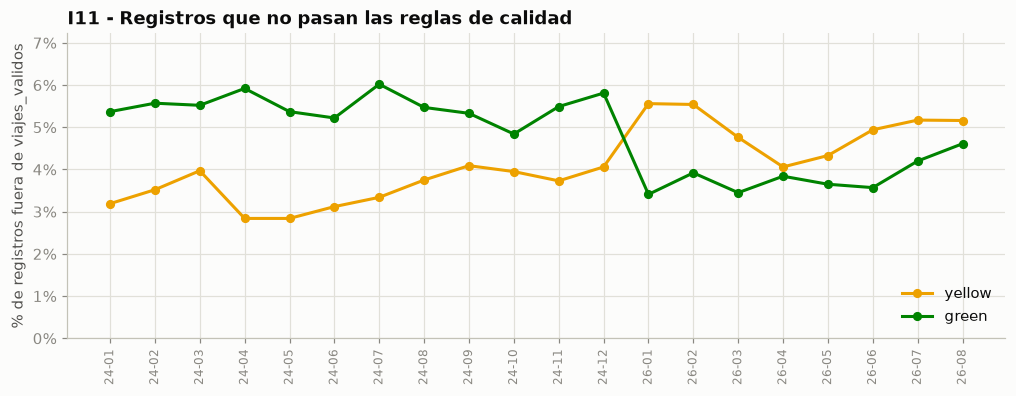

In [23]:
fig, ax = plt.subplots(figsize=(11, 3.6))
meses = sorted(i11.mes.unique())
for tipo, color in COLOR_TIPO.items():
    d = i11[i11.tipo == tipo].set_index("mes").reindex(meses)
    ax.plot(range(len(meses)), d.pct_invalidos, color=color, marker="o", markersize=5, label=tipo)
ax.set_xticks(range(len(meses)), [m[2:4] + "-" + m[5:] for m in meses], fontsize=8, rotation=90)
ax.yaxis.set_major_formatter(porcentaje)
ax.set_ylim(0, i11.pct_invalidos.max() * 1.2)
ax.set_ylabel("% de registros fuera de viajes_validos")
ax.set_title("I11 - Registros que no pasan las reglas de calidad")
ax.legend(loc="lower right")
guardar(fig, "ej7_i11_calidad_datos")